# Construir un grafo a partir de un dataset
Hay tres técnicas básicas para obtener un grafo (no dirigido en nuestro caso)  a partir de un dataset: Grafo de vecindad $\varepsilon$, K-Vecinos y Grafo completamente conectado y filtrado por un umbral. Vamos a implementar alguna de ellas.

Primero vamos a cargar el conocido dataset 'Iris' que contiene datos morfológicos de tres especies de plantas de la especie 'Iris'.

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
150


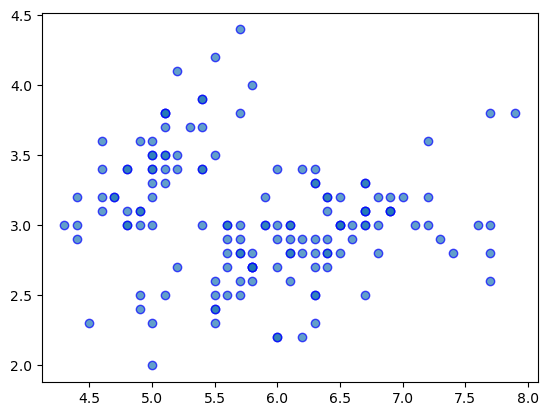

In [1]:
from matplotlib import pyplot as plt
from sklearn import datasets
import numpy as np
bunch = datasets.load_iris()
#print(bunch)
X, y=datasets.load_iris(return_X_y=True)
print(bunch.feature_names)

plt.scatter(X[:,0], X[:,1], alpha=0.7, edgecolors='b')
print(X[:,0].size)
#plt.xlabel('Weight')
#plt.ylabel('Height')

## Grafo K-Vecinos más próximos
Podemos construir la matriz de adyacencia del grafo de los K-vecinos más próximos (la similaridad es la vecindad). Para ello la librería sklearn nos proporciona una clase que nos permite generar esta matriz (kneighbors_graph)

In [2]:
from sklearn.neighbors import kneighbors_graph
from scipy import sparse
connectivity = kneighbors_graph(X=bunch['data'], n_neighbors=8, mode='connectivity')
print(connectivity)
print("+++++++++++++")
#como es una matriz de vecinos más próximos, es un grafo dirigido y la matriz no es simétrica en general
#Vamos a transformarla en simétrica promediando las dos distancias 
adjacency_matrix_s = (1/2)*(connectivity + connectivity.T)  #Expresión 1

adjacency_matrix_s = adjacency_matrix_s.toarray()

#Hay términos que valen 0.5. Vamos a convertirlos a 0
adjacency_matrix_final = adjacency_matrix_s.astype(int)
#print(adjacency_matrix_final)
#print("**************")
#for cell in np.nditer(adjacency_matrix_s,flags=['refs_ok'], op_flags=['readwrite']):
#    if cell < 0.9:
#        cell[...] =0.0

#print(adjacency_matrix_final == adjacency_matrix_s)
print(adjacency_matrix_final.sum())
print(adjacency_matrix_final.shape)
#imprimimos una fila para que se vean todos los valores correspondientes a un nodo
print(adjacency_matrix_final[10,:])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1200 stored elements and shape (150, 150)>
  Coords	Values
  (0, 17)	1.0
  (0, 4)	1.0
  (0, 39)	1.0
  (0, 28)	1.0
  (0, 27)	1.0
  (0, 40)	1.0
  (0, 7)	1.0
  (0, 49)	1.0
  (1, 34)	1.0
  (1, 45)	1.0
  (1, 12)	1.0
  (1, 9)	1.0
  (1, 25)	1.0
  (1, 30)	1.0
  (1, 35)	1.0
  (1, 2)	1.0
  (2, 47)	1.0
  (2, 3)	1.0
  (2, 12)	1.0
  (2, 6)	1.0
  (2, 45)	1.0
  (2, 42)	1.0
  (2, 29)	1.0
  (2, 34)	1.0
  (3, 47)	1.0
  :	:
  (146, 142)	1.0
  (147, 110)	1.0
  (147, 111)	1.0
  (147, 116)	1.0
  (147, 145)	1.0
  (147, 115)	1.0
  (147, 137)	1.0
  (147, 77)	1.0
  (147, 112)	1.0
  (148, 136)	1.0
  (148, 115)	1.0
  (148, 110)	1.0
  (148, 147)	1.0
  (148, 140)	1.0
  (148, 137)	1.0
  (148, 124)	1.0
  (148, 144)	1.0
  (149, 127)	1.0
  (149, 138)	1.0
  (149, 101)	1.0
  (149, 142)	1.0
  (149, 70)	1.0
  (149, 83)	1.0
  (149, 121)	1.0
  (149, 126)	1.0
+++++++++++++
800
(150, 150)
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1
 0 

Observa cómo hemos transformado la matriz original de K-Vecinos (no simétrica en general) a una matriz de adyacencia que sí es simétrica.

A la vista del código utilizado explica cuál de las dos opciones posibles se ha empleado en la construcción de esta matriz (consulta la presentación de teoría para recordarlas).

**Respuesta:**

En la construcción de la matriz de adyacencia simétrica se ha utilizado la opción de la unión de vecinos.
Es decir, dos nodos se conectan si al menos uno de ellos considera al otro como uno de sus K vecinos más próximos.

Escribe un ejemplo numérico con matrices 3x3 que ilustre la transformación de una matriz no simétrica a otra simétrica 
utilizando la suma de ella misma con su traspuesta  dividido por dos. Para ello define una matriz real 3x3 que no sea 
simétrica y aplica la 'Expresión 1' señalada en elcódigo de la caja anterior.

**Respuesta:**
A = 
⎡ 0 1 0 ⎤
⎢ 0 0 1 ⎥
⎣ 1 0 0 ⎦
Aᵗ =
⎡ 0 0 1 ⎤
⎢ 1 0 0 ⎥
⎣ 0 1 0 ⎦

A + Aᵗ =
⎡ 0 1 1 ⎤
⎢ 1 0 1 ⎥
⎣ 1 1 0 ⎦

Aₛ = (1/2) × (A + Aᵗ) =
⎡ 0 0.5 0.5 ⎤
⎢ 0.5 0 0.5 ⎥
⎣ 0.5 0.5 0 ⎦


### Visualización del grafo
Con la matriz de adyacencias podemos construir el grafo. Para ello debemos cargar la libreria networkx. Con ella creamos la siguiente función que necesita como argumento la matriz de adyacencia. Se pueden etiquetar también los vértices modificando la llamada a la función interior 'nx.draw'. Mirar la documentación si estáis interesad@s.

Nota que en cada ejecución de la caja de abajo, la forma del grafo cambia. Esto es porque la matriz de adyacencia solo proporciona información de conectividad, y no de la posición espacial de los vértices.

**Nota (10/2021)** Segun tu instalcion puede darte un fallo de ejecución en la instrucción nx.Graph(). Intenta actualizar de la librería el paquete llamado 'decorator'

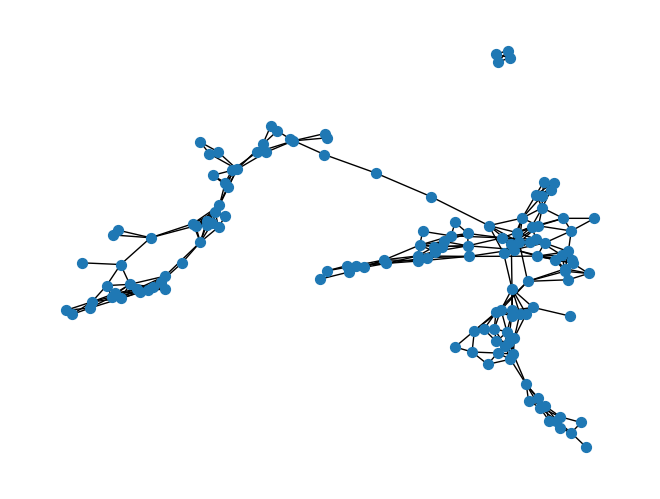

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
def show_graph_with_labels(adjacency_matrix):
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=50,  with_labels=False)
    plt.show()
    
show_graph_with_labels(adjacency_matrix_final)